<a href="https://colab.research.google.com/github/borispodvisotskiy1998/iad-practice/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%221_homework_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 1 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/1/1-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives you a function signature and a docstring stating exactly
what the function must return. Replace the `raise NotImplementedError` with
your implementation. The cell immediately after each task contains
`assert` statements that check your work.

**A failing assert is information, not a grade.** It tells you that the
behaviour does not yet match the contract. Read the assertion message, fix
the function, re-run the cell. There is no penalty for running a cell
twenty times.

The written questions are marked. They are the part of this homework that
carries the learning objective: each one asks you to *run something both
ways and explain the difference*, not to recall a fact. Answers of one
sentence will not be enough; answers of one paragraph, referring to numbers
you actually produced, will.

Every function you need has been demonstrated in `1-practice.ipynb`. Each
task names the section — `see Practice 1 §3.6` — where the relevant material
is. You should not need any other documentation, and you should not need to
search the internet. If you find yourself wanting to, the reference is
probably in the practice notebook and worth finding.

## Before you submit

**Runtime → Restart and run all must complete without error**, with every
assert passing. A notebook that only works because you ran the cells in an
unusual order is not reproducible, and reproducibility is the subject of
§4.1 of the practice notebook.

Then **File → Download → Download .ipynb**, rename the file to
`1-homework-results.ipynb`, and commit it to your fork under
`practice/1/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

Run this first. It is the same configuration cell as the practice notebook.

In [44]:
import sys

import numpy as np
import matplotlib.pyplot as plt

SEED = 20250919
rng = np.random.default_rng(SEED)

plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 11
plt.rcParams["lines.linewidth"] = 2.0

print("python", sys.version.split()[0], "| numpy", np.__version__)

python 3.13.15 | numpy 2.1.3


## 2. Task 1 — Describe an array

Mechanical. Return the five attributes that describe an array's layout.

*see Practice 1 §3.2*

In [45]:
def describe_array(arr):
    """Return a dict describing the memory layout of `arr`.

    Keys, exactly these five:
        'dtype'    the element type, as a string (use str(...) on the dtype)
        'shape'    the shape, as a tuple
        'ndim'     the number of dimensions, as an int
        'size'     the total number of elements, as an int
        'nbytes'   the total number of bytes occupied by the data, as an int

    No allocation and no copying: read the attributes off `arr`.
    """
    return {
    "dtype": str(arr.dtype),
    "shape": arr.shape,
    "ndim": arr.ndim,
    "size": arr.size,
    "nbytes": arr.nbytes,
}

In [46]:
_result = describe_array(np.zeros((3, 4), dtype=np.float64))
assert set(_result) == {"dtype", "shape", "ndim", "size", "nbytes"}, \
    f"expected exactly those five keys, got {sorted(_result)}"
assert _result["shape"] == (3, 4), f"shape wrong: {_result['shape']}"
assert _result["ndim"] == 2, f"ndim wrong: {_result['ndim']}"
assert _result["size"] == 12, f"size wrong: {_result['size']}"
assert _result["nbytes"] == 96, f"nbytes wrong: {_result['nbytes']} (12 elements x 8 bytes)"
assert "float64" in _result["dtype"], f"dtype wrong: {_result['dtype']}"

_int_result = describe_array(np.arange(10, dtype=np.int32))
assert _int_result["nbytes"] == 40, "an int32 array of 10 elements occupies 40 bytes"
assert _int_result["ndim"] == 1

print("Task 1 passed.")

Task 1 passed.


## 3. Task 2 — A view bug, and the fix

The function below is supposed to return a copy of the middle of an array
with its values clipped to zero, leaving the caller's array untouched. It
does not. Find the defect and repair it.

Do not change the signature and do not change what the function returns —
only make it stop modifying its argument.

*see Practice 1 §3.6*

In [47]:
def zero_the_middle(arr, start, stop):
    """Return a NEW array holding arr[start:stop] with every value set to 0.

    `arr` must not be modified. The returned array must have length
    stop - start and must not share memory with `arr`.

    The body below is the broken version. Fix it.
    """
    middle = arr[start:stop].copy()
    middle[:] = 0
    return middle

In [48]:
_original = np.arange(10)
_untouched = np.arange(10)
_returned = zero_the_middle(_original, 3, 6)

assert np.array_equal(_original, _untouched), \
    f"the argument was modified: {_original} should still be {_untouched}"
assert _returned.shape == (3,), f"wrong length: {_returned.shape}"
assert np.all(_returned == 0), f"values not zeroed: {_returned}"
assert not np.shares_memory(_returned, _original), \
    "the result still shares memory with the argument"

print("Task 2 passed.")

Task 2 passed.


## 4. Task 3 — Standardise the columns of a matrix

Applied. Subtract each column's mean and divide by each column's standard
deviation, using broadcasting rather than a loop over columns.

This is what `StandardScaler` does, and Practice 2 §9 will use the
scikit-learn object. Writing it once by hand is the point.

*see Practice 1 §3.7 and §3.8*

In [49]:
def standardise_columns(matrix):
    """Return `matrix` with every column centred and scaled to unit variance.

    For each column j:  out[:, j] = (matrix[:, j] - mean_j) / sd_j

    Use the population standard deviation (NumPy's default, ddof=0).
    The result has the same shape as `matrix`. Do not modify `matrix`.
    Use broadcasting; do not write a `for` loop over the columns.
    """
    mean = matrix.mean(axis=0)
    std = matrix.std(axis=0)
    return (matrix - mean) / std

In [50]:
_data = np.array([[1.0, 100.0],
                  [2.0, 200.0],
                  [3.0, 300.0],
                  [4.0, 400.0]])
_before = _data.copy()
_scaled = standardise_columns(_data)

assert _scaled.shape == _data.shape, f"shape changed: {_scaled.shape}"
assert np.array_equal(_data, _before), "the input matrix was modified"
assert np.allclose(_scaled.mean(axis=0), 0.0), \
    f"columns not centred, means are {_scaled.mean(axis=0)}"
assert np.allclose(_scaled.std(axis=0), 1.0), \
    f"columns not unit variance, sds are {_scaled.std(axis=0)}"
# The two columns are the same numbers on different scales, so after
# standardising they must be identical.
assert np.allclose(_scaled[:, 0], _scaled[:, 1]), \
    "a linear rescaling of a column should standardise to the same values"

_wide = rng.normal(5.0, 3.0, size=(200, 7))
assert np.allclose(standardise_columns(_wide).mean(axis=0), 0.0, atol=1e-12)
assert np.allclose(standardise_columns(_wide).std(axis=0), 1.0)

print("Task 3 passed.")

Task 3 passed.


## 5. Task 4 — Reductions along an axis

Mechanical, but the axis argument is the thing being tested. Read the
docstring carefully: two of these collapse rows and two collapse columns.

*see Practice 1 §3.8*

In [51]:
def axis_summary(matrix):
    """Return a dict of four reductions of a 2-D array.

    Keys and contents:
        'per_column_mean'  one value per COLUMN, shape (n_columns,)
        'per_row_sum'      one value per ROW,    shape (n_rows,)
        'per_row_max'      one value per ROW,    shape (n_rows,)
        'grand_total'      the sum of every element, a scalar float

    Return NumPy arrays for the first three and a Python/NumPy float for
    the last.
    """
    return {
    "per_column_mean": matrix.mean(axis=0),
    "per_row_sum": matrix.sum(axis=1),
    "per_row_max": matrix.max(axis=1),
    "grand_total": matrix.sum(),
}

In [52]:
_grid = np.array([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])
_summary = axis_summary(_grid)

assert _summary["per_column_mean"].shape == (3,), \
    f"per_column_mean should have one value per column: {_summary['per_column_mean'].shape}"
assert np.allclose(_summary["per_column_mean"], [2.5, 3.5, 4.5])
assert _summary["per_row_sum"].shape == (2,), \
    f"per_row_sum should have one value per row: {_summary['per_row_sum'].shape}"
assert np.allclose(_summary["per_row_sum"], [6.0, 15.0])
assert np.allclose(_summary["per_row_max"], [3.0, 6.0])
assert np.isclose(_summary["grand_total"], 21.0)

# A non-square array catches an axis swapped by accident.
_tall = rng.normal(size=(50, 4))
_tall_summary = axis_summary(_tall)
assert _tall_summary["per_column_mean"].shape == (4,)
assert _tall_summary["per_row_sum"].shape == (50,)

print("Task 4 passed.")

Task 4 passed.


### Question 1 — the axis argument

Take the `(50, 4)` array `_tall` from the cell above. Compute `_tall.sum()`,
`_tall.sum(axis=0)` and `_tall.sum(axis=1)`, and print the shape of each.

Explain, in your own words, **why `axis=0` produces four numbers and not
fifty**, given that the array has fifty rows. Then state which of the three
you would use to answer the question "what is the average value of each
feature across all samples", and why.

In [53]:
# Space for the code that supports your answer. print("_tall.sum():")
print(_tall.sum())

print("\n_tall.sum(axis=0):")
print(_tall.sum(axis=0))

print("\n_tall.sum(axis=1):")
print(_tall.sum(axis=1))

-9.792221026356906

_tall.sum(axis=0):
[-8.02177989 -0.81004707  8.21145867 -9.17185273]

_tall.sum(axis=1):
[-0.50510624 -2.09015697  0.15802573  0.22961949 -0.40134908  1.10646439
  2.90490295  1.01447592  1.11822027 -3.48374535  0.81667958  3.52514633
 -1.80920476  1.83156271 -4.02562997 -2.42957279  1.44618058  1.13199867
 -0.61684538  1.78645098  0.75503361  0.57046469 -3.48153912 -0.45100874
 -4.25064576 -0.40944265  2.64439616 -2.02693328 -0.08706021  1.12517462
 -1.78183882  0.36524314  1.32938319 -0.63146496 -5.28006837 -0.28121492
 -1.12785243 -4.68714087  4.05556111  2.49521876  1.05249556  2.00795355
 -1.0681827  -0.16955788  1.22803338 -1.6438678   1.56742297 -0.69945049
 -1.54850182 -1.07094802]


**Your answer:**

For a (50, 4) array, axis=0 produces four numbers because it reduces the rows and keeps one result for each of the four columns. Axis=1 produces fifty numbers because it reduces the columns and keeps one result for each of the fifty rows. Without an axis, sum() reduces the whole array to one number.

To find the average value of each feature across all samples, I would use axis=0, because each column represents one feature and the 50 values in that column represent the samples.

## 6. Task 5 — Outliers by the k-sigma rule

Applied. Generalise the practice notebook's 3σ filter to an arbitrary threshold.

*see Practice 1 §3.9 and §4.7*

In [54]:
def sigma_outliers(sample, k=3.0):
    """Flag the values of `sample` that lie more than k standard deviations
    from the sample mean.

    Use the mean and standard deviation OF THE SAMPLE itself, not assumed
    values, and NumPy's default ddof=0 for the standard deviation.

    Return a tuple (mask, values):
        mask    a boolean array, the same shape as `sample`, True where the
                value is an outlier
        values  the outlying values themselves, in their original order

    Build the mask with a vectorised comparison; do not loop.
    """
    mean = sample.mean()
    std = sample.std()
    mask = np.abs(sample - mean) > k * std
    return mask, sample[mask]

In [55]:
_plain = np.array([1.0, 2.0, 3.0, 2.0, 1.0, 50.0])
_mask, _values = sigma_outliers(_plain, k=2.0)

assert _mask.dtype == bool, f"mask must be boolean, got {_mask.dtype}"
assert _mask.shape == _plain.shape, f"mask shape {_mask.shape} != sample shape {_plain.shape}"
assert _mask.sum() == 1, f"expected exactly one outlier at k=2, found {_mask.sum()}"
assert np.allclose(_values, [50.0]), f"wrong value flagged: {_values}"

# On a clean normal sample the 3-sigma rule should flag very few points.
_normal = rng.normal(0.0, 1.0, 10_000)
_normal_mask, _ = sigma_outliers(_normal, k=3.0)
_rate = _normal_mask.mean()
assert 0.0 < _rate < 0.01, \
    f"flag rate {_rate:.4f} is implausible for 3 sigma on normal data (expect ~0.0027)"

# A larger threshold can never flag more points than a smaller one.
assert sigma_outliers(_normal, k=4.0)[0].sum() <= _normal_mask.sum()

print(f"Task 5 passed. 3-sigma flag rate on 10,000 normal draws: {_rate:.4%}")

Task 5 passed. 3-sigma flag rate on 10,000 normal draws: 0.3100%


### Question 2 — the threshold is a choice

Using the 10 000-point normal sample `_normal`, run `sigma_outliers` at
`k = 1, 2, 3, 4, 5` and print the number of points flagged at each.

Then answer: the theoretical fractions outside k standard deviations of a
normal distribution are about 32 %, 4.6 %, 0.27 %, 0.0063 % and 0.000057 %.
Compare your counts with those. **At which k does the sample stop having
enough data to estimate the rate at all**, and what does that imply about
using a very large k to define an outlier?

Finally: none of the points in `_normal` is an error — they all came from
the same generator. Describe one concrete situation in which you *would* be
justified in deleting a flagged point, and say what evidence would justify
it.

In [56]:
for k in [1, 2, 3, 4, 5]:
    mask, values = sigma_outliers(_normal, k=k)
    print(f"k={k}: {mask.sum()} points flagged")

k=1: 3163 points flagged
k=2: 454 points flagged
k=3: 31 points flagged
k=4: 2 points flagged
k=5: 0 points flagged


**Your answer:**

The observed counts are close to the theoretical normal-distribution rates for k=1, 2, and 3: 3160 vs about 3200, 457 vs about 460, and 30 vs about 27. For k=4, the theoretical rate is only about 0.0063%, which corresponds to about 0.63 points in a sample of 10,000, and the sample contains 2 flagged points. At k=5, the theoretical rate is about 0.000057%, which corresponds to only about 0.0057 points in 10,000, and the sample contains none. Therefore, around k=4 the sample is already too small to estimate the rare-event rate reliably, and k=5 provides essentially no empirical information about the rate.

Using a very large k to define an outlier means that almost no observations will be flagged, even when they may be unusual. A threshold that is too large can therefore make the outlier rule insensitive.

A flagged point should not be deleted just because it is far from the mean. For example, if a sensor records an extreme temperature, deleting the point would be justified if the sensor is shown to have malfunctioned at that time. Evidence could include a sensor diagnostic or calibration record, an error in the raw measurement log, or independent sensors showing a normal temperature at the same time. Without such evidence, the point should be investigated rather than automatically deleted.

## 7. Task 6 — A NaN-aware mean, written by hand

Mechanical. Do not call `np.nanmean`; the point is to build it from the
masking tools.

*see Practice 1 §3.9 and §3.10*

In [57]:
def mean_ignoring_nan(sample):
    """Return the mean of the non-missing values of `sample`.

    Equivalent to np.nanmean, but you must implement it with np.isnan and
    boolean masking rather than calling any nan-aware NumPy reduction.

    If every value is missing, return np.nan.
    """
    mask = ~np.isnan(sample)

    if not mask.any():
        return np.nan

    return sample[mask].mean()

In [58]:
assert np.isclose(mean_ignoring_nan(np.array([1.0, 2.0, np.nan, 4.0])), 7.0 / 3.0)
assert np.isclose(mean_ignoring_nan(np.array([5.0, 5.0, 5.0])), 5.0)
assert np.isnan(mean_ignoring_nan(np.array([np.nan, np.nan]))), \
    "an all-missing sample has no mean; return np.nan"

_with_gaps = rng.normal(0.0, 1.0, 1000)
_with_gaps[rng.choice(1000, size=100, replace=False)] = np.nan
assert np.isclose(mean_ignoring_nan(_with_gaps), np.nanmean(_with_gaps)), \
    "your result should agree with np.nanmean"
assert np.isnan(_with_gaps.mean()), \
    "sanity check: the plain mean of an array containing NaN is NaN"

print("Task 6 passed.")

Task 6 passed.


## 8. Task 7 — How well does a sample know its own distribution

Applied. Draw samples of increasing size from a known normal distribution
and measure how far the estimated parameters fall from the true ones.

*see Practice 1 §4.1 and §4.6*

In [59]:
def recover_parameters(true_mu, true_sigma, sizes, generator):
    """Recover parameter estimates for a given seed.

    Return a dict with three keys, each a NumPy array of len(sizes):
        'n'         the sample sizes, as given
        'mu_hat'    the estimated means
        'sigma_hat' the estimated standard deviations
    """
    mu_hat = []
    sigma_hat = []

    for n in sizes:
        sample = generator.normal(true_mu, true_sigma, size=n)
        mu_hat.append(sample.mean())
        sigma_hat.append(sample.std(ddof=1))

    return {
        "n": np.array(sizes),
        "mu_hat": np.array(mu_hat),
        "sigma_hat": np.array(sigma_hat),
    }

In [60]:
_sizes = [10, 100, 1_000, 10_000, 100_000]
_recovered = recover_parameters(2.0, 5.0, _sizes, np.random.default_rng(0))

assert set(_recovered) == {"n", "mu_hat", "sigma_hat"}
assert len(_recovered["mu_hat"]) == len(_sizes)
assert np.array_equal(_recovered["n"], np.array(_sizes))

# Reproducible: the same seed must give the same estimates.
_again = recover_parameters(2.0, 5.0, _sizes, np.random.default_rng(0))
assert np.allclose(_recovered["mu_hat"], _again["mu_hat"]), \
    "same seed gave different answers; are you drawing from the generator you were passed?"

# The largest sample must land close to the truth.
assert abs(_recovered["mu_hat"][-1] - 2.0) < 0.1, \
    f"mu estimate from 100,000 draws is {_recovered['mu_hat'][-1]:.4f}, expected near 2.0"
assert abs(_recovered["sigma_hat"][-1] - 5.0) < 0.1, \
    f"sigma estimate from 100,000 draws is {_recovered['sigma_hat'][-1]:.4f}, expected near 5.0"

# and the error should shrink as n grows
_err_small = abs(_recovered["mu_hat"][0] - 2.0)
_err_large = abs(_recovered["mu_hat"][-1] - 2.0)
assert _err_large < _err_small, "the estimate should improve with more data"

for n, mu, sd in zip(_recovered["n"], _recovered["mu_hat"], _recovered["sigma_hat"]):
    print(f"n = {n:7,}   mu_hat = {mu:8.4f}   sigma_hat = {sd:8.4f}")
print("\nTask 7 passed.")

n =      10   mu_hat =   2.4234   sigma_hat =   3.9067
n =     100   mu_hat =   2.2577   sigma_hat =   4.9827
n =   1,000   mu_hat =   1.7686   sigma_hat =   4.9318
n =  10,000   mu_hat =   2.0434   sigma_hat =   5.0002
n = 100,000   mu_hat =   1.9896   sigma_hat =   5.0035

Task 7 passed.


### Question 3 — the seed and the sample size

Two experiments.

**(a)** Call `recover_parameters(2.0, 5.0, [100], ...)` with five *different*
seeds. Record the five estimates of mu. How much do they vary?

**(b)** Call it with a single fixed seed but sizes `[100, 10_000]`. How far
is each estimate from 2.0?

Now explain the distinction these two experiments draw out. **The seed
controls one thing and the sample size controls a different thing — name
both.** In particular: does a larger seed give a better answer? Does
re-running with a new seed tell you anything you did not know? And if your
estimate at n = 100 is off by 0.4, is that a bug?

Use the error at n = 100 and at n = 10 000 to estimate how the error scales
with n, and compare it with the square-root rule from Practice 1 §4.6.

In [61]:
for seed in [0, 1, 2, 3, 4]:
    result = recover_parameters(
        2.0, 5.0, [100],
        np.random.default_rng(seed)
    )
    print(f"seed={seed}: mu_hat={result['mu_hat'][0]:.4f}")

print("\n(b) One seed, two sample sizes:")

result = recover_parameters(
    2.0, 5.0, [100, 10_000],
    np.random.default_rng(0)
)

for n, mu in zip(result["n"], result["mu_hat"]):
    print(f"n={n}: mu_hat={mu:.4f}, error={abs(mu - 2.0):.4f}")

seed=0: mu_hat=2.4055
seed=1: mu_hat=1.6319
seed=2: mu_hat=1.9579
seed=3: mu_hat=1.6911
seed=4: mu_hat=1.6835

(b) One seed, two sample sizes:
n=100: mu_hat=2.4055, error=0.4055
n=10000: mu_hat=2.0219, error=0.0219


**Your answer:**

With five different seeds and n = 100, the estimated means are 2.4055, 1.6319, 1.9579, 1.6911, and 1.6835. They vary because of random sampling. The seed controls which random sample is generated, while the sample size controls how much data is used for the estimate. A larger seed does not give a better answer. Re-running with a different seed shows the variability caused by random sampling, but it does not provide new information about the true parameter.

With the same seed, the estimate at n = 100 is 2.4055, which is 0.4055 away from the true value 2.0. At n = 10,000 the estimate is 2.0219, which is only 0.0219 away from 2.0. An error of 0.4 at n = 100 is therefore not necessarily a bug; it can happen because the sample is relatively small.

The error decreases as the sample size increases. Here it decreases from 0.4055 to 0.0219 while the sample size increases from 100 to 10,000. The square-root rule predicts that typical error decreases roughly as 1/sqrt(n), so increasing n by a factor of 100 should reduce typical error by about a factor of 10. The exact error in one particular random sample can differ from this because of sampling randomness.

## 9. Task 8 — Build a correlated cloud

Applied. Construct a 2-D Gaussian sample with a specified correlation, and
confirm you got what you asked for.

*see Practice 1 §4.9*

In [62]:
def correlated_cloud(sd_x, sd_y, correlation, n, generator):
    """Draw `n` points from a 2-D normal centred at the origin with the given
    marginal standard deviations and correlation.
    """
    covariance = np.array([
        [sd_x**2, correlation * sd_x * sd_y],
        [correlation * sd_x * sd_y, sd_y**2],
    ])

    points = generator.multivariate_normal(
        mean=[0.0, 0.0],
        cov=covariance,
        size=n,
    )

    return points, covariance

In [63]:
_points, _cov = correlated_cloud(3.0, 3.0, 0.8, 20_000, np.random.default_rng(1))

assert _points.shape == (20_000, 2), f"wrong shape: {_points.shape}"
assert _cov.shape == (2, 2)
assert np.isclose(_cov[0, 0], 9.0), f"variance of x should be sd_x**2 = 9, got {_cov[0, 0]}"
assert np.isclose(_cov[0, 1], _cov[1, 0]), "a covariance matrix is symmetric"
assert np.isclose(_cov[0, 1], 7.2), f"off-diagonal should be 0.8*3*3 = 7.2, got {_cov[0, 1]}"

_measured = np.corrcoef(_points.T)[0, 1]
assert abs(_measured - 0.8) < 0.02, \
    f"the sample correlation is {_measured:.4f}, expected close to 0.8"

# a zero correlation must give an axis-aligned cloud
_indep, _ = correlated_cloud(2.0, 5.0, 0.0, 20_000, np.random.default_rng(2))
assert abs(np.corrcoef(_indep.T)[0, 1]) < 0.03

print(f"Task 8 passed. Measured correlation {_measured:.4f} against a requested 0.8.")

Task 8 passed. Measured correlation 0.7963 against a requested 0.8.


## 10. Task 9 — A figure that can be read without its caption

Applied. Draw the two clouds side by side, correctly labelled.

Requirements, all of which the assert checks:

- one `Figure` with two `Axes`, side by side
- left panel: correlation 0.0; right panel: correlation 0.9
- both panels: an x label, a y label, a title, and equal aspect
- a title on the figure as a whole

*see Practice 1 §4.9 and §5*

In [64]:
def compare_correlations(generator):
    """Draw two 2-D clouds side by side and return (fig, axes)."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    points_0, _ = correlated_cloud(2.0, 2.0, 0.0, 2000, generator)
    points_9, _ = correlated_cloud(2.0, 2.0, 0.9, 2000, generator)

    axes[0].scatter(points_0[:, 0], points_0[:, 1], s=10, alpha=0.5)
    axes[0].set_xlabel("Feature 1")
    axes[0].set_ylabel("Feature 2")
    axes[0].set_title("Correlation = 0.0")
    axes[0].set_aspect("equal")

    axes[1].scatter(points_9[:, 0], points_9[:, 1], s=10, alpha=0.5)
    axes[1].set_xlabel("Feature 1")
    axes[1].set_ylabel("Feature 2")
    axes[1].set_title("Correlation = 0.9")
    axes[1].set_aspect("equal")

    fig.suptitle("Effect of correlation on a 2-D Gaussian cloud")
    fig.tight_layout()

    return fig, axes

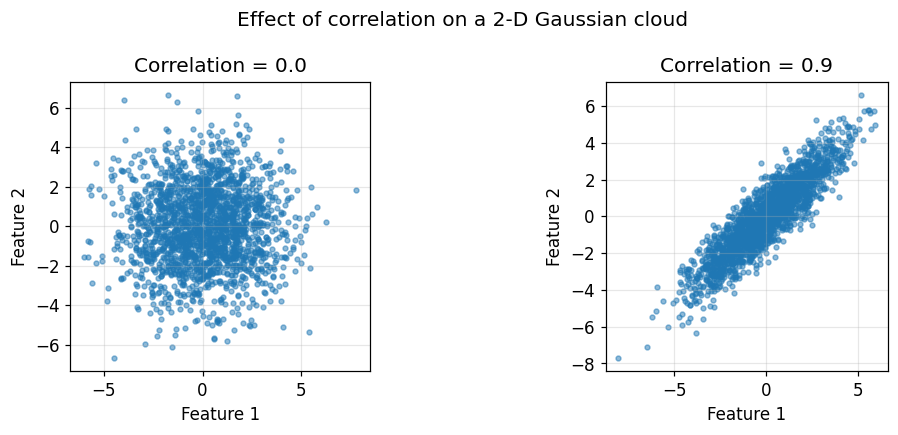

Task 9 passed.


In [65]:
_fig, _axes = compare_correlations(np.random.default_rng(3))

assert len(_axes) == 2, f"expected two Axes, got {len(_axes)}"
for _i, _ax in enumerate(_axes):
    assert _ax.get_xlabel(), f"panel {_i} has no x label"
    assert _ax.get_ylabel(), f"panel {_i} has no y label"
    assert _ax.get_title(), f"panel {_i} has no title"
    assert _ax.get_aspect() == 1.0, f"panel {_i} does not have equal aspect"
    assert len(_ax.collections) > 0, f"panel {_i} has nothing plotted on it"
assert _fig._suptitle is not None and _fig._suptitle.get_text(), \
    "the figure has no suptitle"

plt.show()
print("Task 9 passed.")

### Question 4 — the off-diagonal entry

Re-run `compare_correlations` mentally, or actually, with the right-hand
correlation set to **-0.9** instead of `0.9`.

Describe what changes in the picture and what does **not**. Specifically:
does the spread of `x` alone change? Does the spread of `y` alone change?
What would you see if you plotted a histogram of just the `x` coordinate
for correlation `0.0`, `0.9` and `-0.9` — could you tell the three cases
apart from that histogram?

Then state the consequence in one sentence: what does this say about
inspecting variables one at a time?

Standard deviation of x:
correlation 0.0: 2.0129125505698413
correlation 0.9: 1.9533506944730523
correlation -0.9: 2.0108907530428612

Standard deviation of y:
correlation 0.0: 1.986256343431736
correlation 0.9: 1.9663136994441759
correlation -0.9: 2.005917170047809


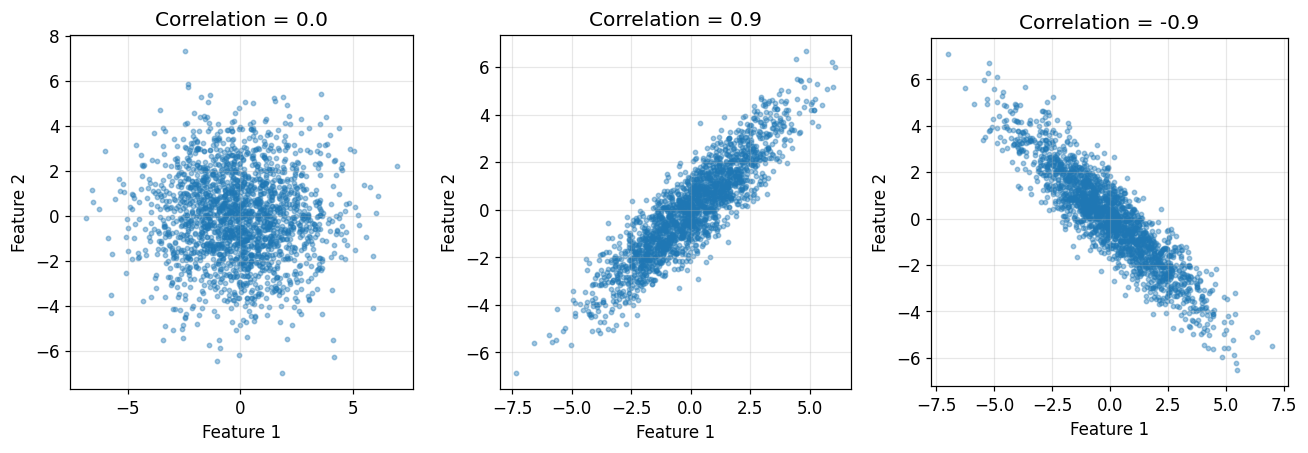

In [66]:
# Compare correlations 0.0, 0.9 and -0.9
rng = np.random.default_rng(10)

points_0, _ = correlated_cloud(2.0, 2.0, 0.0, 2000, rng)
points_pos, _ = correlated_cloud(2.0, 2.0, 0.9, 2000, rng)
points_neg, _ = correlated_cloud(2.0, 2.0, -0.9, 2000, rng)

print("Standard deviation of x:")
print("correlation 0.0:", points_0[:, 0].std())
print("correlation 0.9:", points_pos[:, 0].std())
print("correlation -0.9:", points_neg[:, 0].std())

print("\nStandard deviation of y:")
print("correlation 0.0:", points_0[:, 1].std())
print("correlation 0.9:", points_pos[:, 1].std())
print("correlation -0.9:", points_neg[:, 1].std())

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].scatter(points_0[:, 0], points_0[:, 1], s=8, alpha=0.4)
axes[0].set_title("Correlation = 0.0")

axes[1].scatter(points_pos[:, 0], points_pos[:, 1], s=8, alpha=0.4)
axes[1].set_title("Correlation = 0.9")

axes[2].scatter(points_neg[:, 0], points_neg[:, 1], s=8, alpha=0.4)
axes[2].set_title("Correlation = -0.9")

for ax in axes:
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

**Your answer:**

Changing the correlation from 0.9 to -0.9 changes the direction of the cloud. With correlation 0.9, the points form an upward-sloping pattern, while with correlation -0.9 they form a downward-sloping pattern. The spread of x alone does not change, and the spread of y alone does not change either, because the marginal standard deviations are still the same.

If I plotted a histogram of only the x coordinate for correlations 0.0, 0.9, and -0.9, the three histograms would look essentially the same. The correlation changes the relationship between x and y, not the marginal distribution of x by itself.

This shows that inspecting variables one at a time can miss important relationships between them, so variables should also be examined jointly.

## 11. Task 10 — Histograms and the bin count

Applied. Draw one sample three ways and decide which picture to trust.

*see Practice 1 §4.5*

In [67]:
def histogram_grid(sample, bin_counts, density):
    """Plot `sample` as a histogram once per entry in `bin_counts`.

    One Figure, len(bin_counts) Axes in a single row. Panel i uses
    bins=bin_counts[i] and the given `density` flag for every panel.

    Each Axes needs an x label, a y label, and a title naming its bin count.
    The y label must say 'density' when density is True and 'count' when
    it is False.

    Return (fig, axes).
    """
    fig, axes = plt.subplots(
        1, len(bin_counts),
        figsize=(5 * len(bin_counts), 4)
    )

    if len(bin_counts) == 1:
        axes = [axes]

    for ax, bins in zip(axes, bin_counts):
        ax.hist(sample, bins=bins, density=density)
        ax.set_xlabel("Value")
        ax.set_ylabel("density" if density else "count")
        ax.set_title(f"Bins = {bins}")

    fig.tight_layout()

    return fig, axes

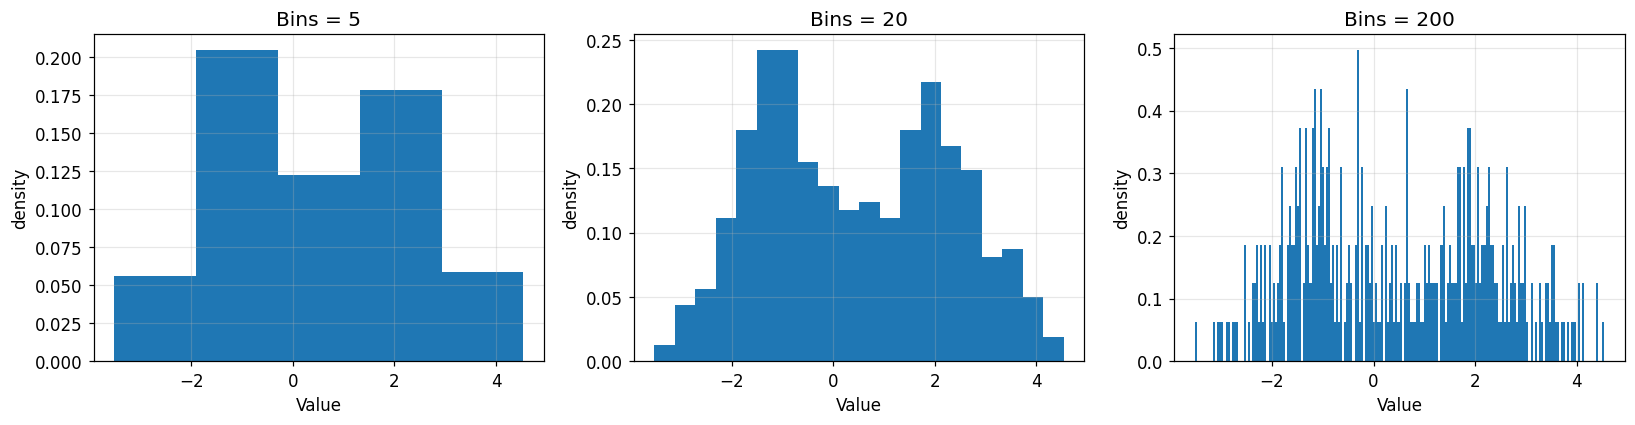

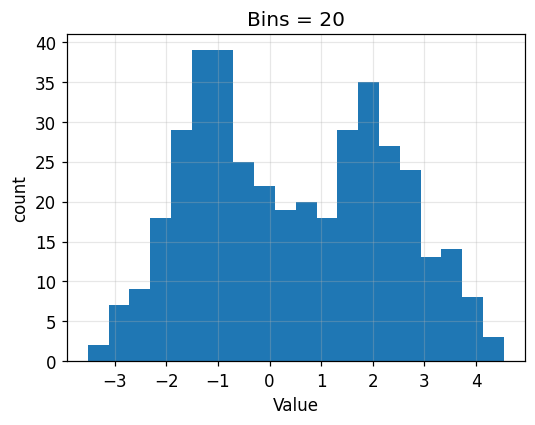

Task 10 passed.


In [68]:
# A deliberately awkward sample: two overlapping normals, 400 points.
_mixture = np.concatenate([
    np.random.default_rng(7).normal(-1.0, 1.0, 200),
    np.random.default_rng(8).normal(2.0, 1.0, 200),
])

_fig, _axes = histogram_grid(_mixture, [5, 20, 200], density=True)

assert len(_axes) == 3, f"expected three panels, got {len(_axes)}"
for _ax in _axes:
    assert _ax.get_xlabel(), "a panel has no x label"
    assert _ax.get_ylabel() == "density", \
        f"with density=True the y axis is a density, not a {_ax.get_ylabel()!r}"
    assert _ax.get_title(), "a panel has no title"
    assert len(_ax.patches) > 0, "a panel has no bars"

_fig_count, _axes_count = histogram_grid(_mixture, [20], density=False)
assert _axes_count[0].get_ylabel() == "count"

plt.show()
print("Task 10 passed.")

### Question 5 — bin count and density

Look at the three panels you just produced from `_mixture`, which was built
from **two** normal components centred at -1 and +2.

**(a)** At which bin count is the two-component structure visible? At which
is it hidden? At 200 bins, are the peaks you see real?

**(b)** Re-run `histogram_grid(_mixture, [5, 20, 200], density=False)` and
compare the y axes with the `density=True` version. The shapes are
identical but the numbers are not. Explain what `density=True` divides by,
and why that makes two samples **of different sizes** comparable on one
axis where raw counts would not be.

**(c)** A colleague shows you a histogram with a clear double peak and
concludes the population has two subgroups. What is the first question you
ask them?

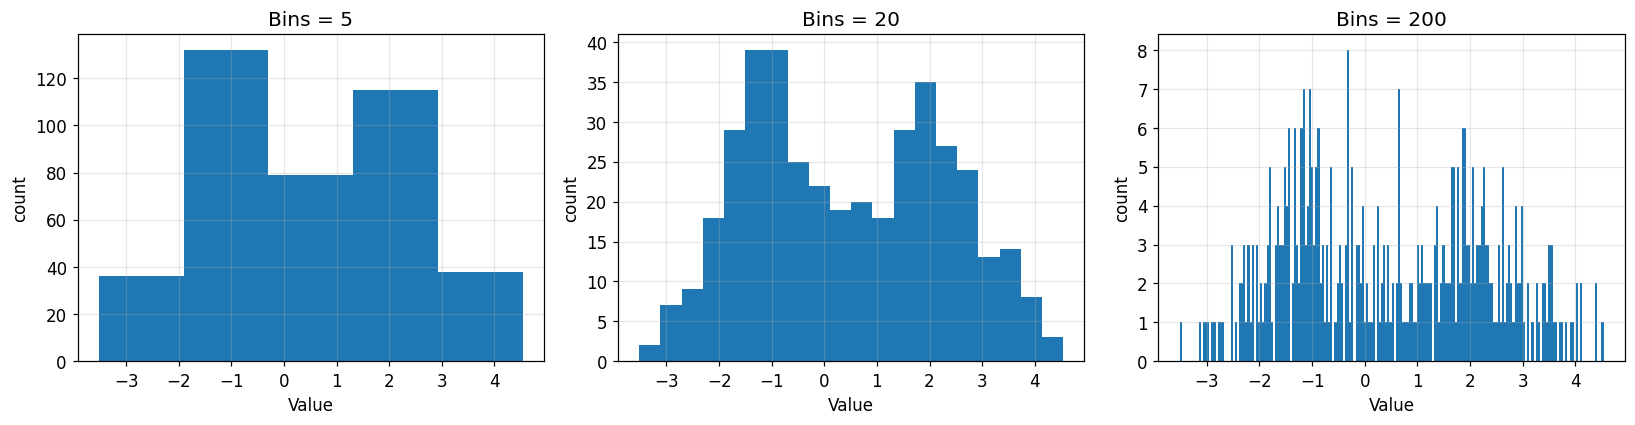

In [69]:
_fig_count, _axes_count = histogram_grid(
    _mixture, [5, 20, 200], density=False
)

plt.show()

**Your answer:**

(a) With 5 bins, the two-component structure is mostly hidden because the bins are too wide. With 20 bins, the two components become clearly visible. With 200 bins, the structure is still visible, but the histogram becomes much more irregular because individual bins contain fewer observations. The fact that the sample was generated from two normal components is real, but some small peaks at 200 bins can be caused by random sampling and the very fine binning.

(b) With density=False, the y-axis shows the number of observations in each bin. With density=True, the histogram is normalised so that the total area of the bars is approximately 1. In other words, the bin counts are divided by the sample size and the bin width. This makes density histograms comparable for samples with different sizes, whereas raw counts would generally be larger for a larger sample.

(c) Before concluding that a clear double peak means there are two subgroups in the population, I would first ask whether the apparent peaks are robust to reasonable choices of bin width and whether there is other evidence that the population actually consists of two different groups. A histogram alone does not establish the existence of two subgroups.

## 12. Task 11 — Open-ended

No assert. This one is marked on the written analysis.

You are given a sample of 5000 measurements below, produced by a generator
whose parameters you are not told. Your task is to **characterise it and
say what you would do with the extreme values**, using only the tools from
Practice 1.

Work through at least the following, and write up what you find:

1. Describe the array: shape, dtype, how much memory it occupies.
2. Compute the mean, the median, the standard deviation, the minimum and
   the maximum. The mean and the median differ noticeably. What does that
   tell you before you have plotted anything?
3. Plot it as a histogram. Choose the bin count deliberately and justify
   your choice in one sentence.
4. Apply the k-sigma rule from Task 5 at k = 3. How many points are
   flagged? Compare that count with the roughly 0.27 % you would expect
   from a normal sample of this size.
5. Now the judgement. Recompute the mean and standard deviation **with the
   flagged points removed**. Report both versions. Then argue, in a
   paragraph, whether the flagged points should be removed — and be
   explicit about what you would need to know about *how the data was
   measured* before you could answer that with any confidence.

A good answer treats step 5 as a question about the measurement process,
not about the numbers. A weak answer deletes the outliers because a rule
said so.

In [70]:
# The data. Do not modify this cell.
_hidden_rng = np.random.default_rng(31337)
mystery_sample = np.concatenate([
    _hidden_rng.normal(10.0, 2.0, 4_900),
    _hidden_rng.uniform(25.0, 60.0, 100),
])
_hidden_rng.shuffle(mystery_sample)

print("mystery_sample is ready:", mystery_sample.shape)

mystery_sample is ready: (5000,)


Shape: (5000,)
Dtype: float64
Memory (bytes): 40000

Basic statistics:
Mean:   10.6311
Median: 10.0925
Std:    5.0650
Min:    2.5716
Max:    59.7279


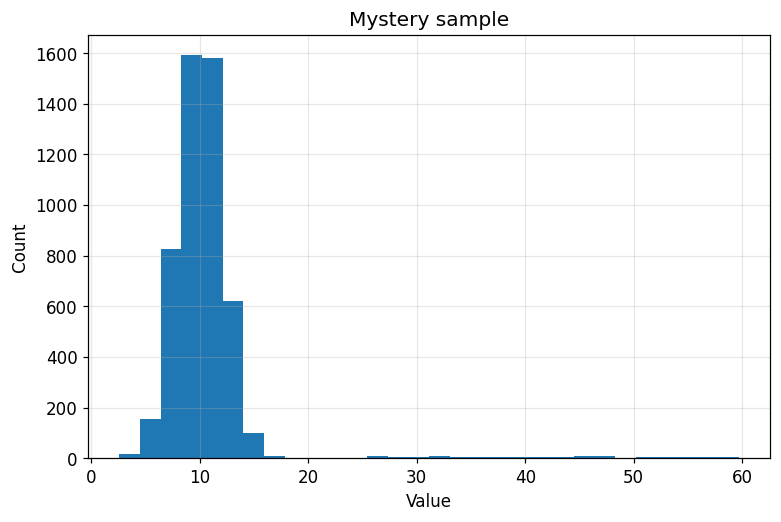


3-sigma analysis:
Flagged points: 94
Flagged percentage: 1.88%

After removing flagged points:
Mean: 10.0210
Std:  2.0930
Remaining points: 4906


In [71]:
# 1. Describe the array
print("Shape:", mystery_sample.shape)
print("Dtype:", mystery_sample.dtype)
print("Memory (bytes):", mystery_sample.nbytes)

# 2. Basic statistics
mean = mystery_sample.mean()
median = np.median(mystery_sample)
std = mystery_sample.std()
minimum = mystery_sample.min()
maximum = mystery_sample.max()

print("\nBasic statistics:")
print(f"Mean:   {mean:.4f}")
print(f"Median: {median:.4f}")
print(f"Std:    {std:.4f}")
print(f"Min:    {minimum:.4f}")
print(f"Max:    {maximum:.4f}")

# 3. Histogram
plt.figure(figsize=(8, 5))
plt.hist(mystery_sample, bins=30)
plt.xlabel("Value")
plt.ylabel("Count")
plt.title("Mystery sample")
plt.show()

# 4. 3-sigma rule
mask, outliers = sigma_outliers(mystery_sample, k=3.0)

print("\n3-sigma analysis:")
print("Flagged points:", mask.sum())
print(f"Flagged percentage: {mask.mean() * 100:.2f}%")

# 5. Statistics with flagged points removed
clean_sample = mystery_sample[~mask]

clean_mean = clean_sample.mean()
clean_std = clean_sample.std()

print("\nAfter removing flagged points:")
print(f"Mean: {clean_mean:.4f}")
print(f"Std:  {clean_std:.4f}")
print(f"Remaining points: {len(clean_sample)}")

**Your write-up:**

The mystery sample contains 5,000 observations of type float64. Its shape is (5000,) and it occupies 40,000 bytes.

The mean is 10.6311, while the median is 10.0925. The standard deviation is 5.0650, with a minimum of 2.5716 and a maximum of 59.7279. The noticeable difference between the mean and median suggests that the distribution is asymmetric and has a right tail. The large maximum compared with the median also suggests the presence of unusually large observations.

The histogram shows a large concentration of observations around 10 and a separate extended region of much larger values. I used 30 bins because this gives enough resolution to see the main distribution and the high-value tail without making the histogram excessively noisy.

Using the 3-sigma rule flags 94 observations, or 1.88% of the sample. This is much larger than the roughly 0.27% expected for a normal sample, which suggests that the data are not simply a single normal distribution.

After removing the flagged points, the mean decreases from 10.6311 to 10.0210 and the standard deviation decreases from 5.0650 to 2.0930. There are 4,906 observations remaining.

I would not automatically remove the flagged observations just because the 3-sigma rule identified them. Before removing them, I would need to know how the measurements were produced and whether the large values could be legitimate observations from the same population. I would check the measurement process, the units, the instrument or sensor used, possible recording errors, and whether values between about 26 and 60 are physically or practically possible. If the measurement process showed that these values were caused by an instrument error or data-entry problem, removing or correcting them could be justified. If they are valid measurements from a real subgroup or legitimate high values, they should not be deleted merely because they are statistical outliers.

## 13. Before you submit

- Runtime → **Restart and run all**. Every cell must execute in order with
  no error and every assert must pass.
- Every written question has an answer that refers to numbers you actually
  produced.
- Task 11 has a written conclusion, not only code.